## Modeling & Comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

# Sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# Tuning
from sklearn.model_selection import GridSearchCV

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

COLORS = {'Positive': '#1D9E75', 'Neutral': '#EF9F27', 'Negative': '#E24B4A'}
LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print(f"✅ TensorFlow version: {tf.__version__}")
print("✅ All imports done")

✅ TensorFlow version: 2.21.0
✅ All imports done


In [2]:

import pickle
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec

# ── Load vectorizers ──────────────────────────────────────────
with open('../models/bow_vectorizer.pkl', 'rb') as f:
    bow_vectorizer = pickle.load(f)
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

# ── Load preprocessed text ────────────────────────────────────
df = pd.read_csv('../data/reviews_preprocessed.csv')

if 'sentiment' not in df.columns:
    def map_sentiment(score):
        if score >= 4:   return 'Positive'
        elif score == 3: return 'Neutral'
        else:            return 'Negative'
    df['sentiment'] = df['Score'].apply(map_sentiment)

label_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df['label'] = df['sentiment'].map(label_map)
df['lemmatized'] = df['lemmatized'].fillna('')

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['lemmatized'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

y_train = y_train.values
y_test  = y_test.values

# ── BoW and TF-IDF matrices ───────────────────────────────────
X_train_bow   = bow_vectorizer.transform(X_train_text)
X_test_bow    = bow_vectorizer.transform(X_test_text)
X_train_tfidf = tfidf_vectorizer.transform(X_train_text)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_text)

# ── Rebuild Word2Vec matrices ─────────────────────────────────
print("Building Word2Vec matrices... (~2 min)")

train_tokens = [t.split() for t in X_train_text]
test_tokens  = [t.split() for t in X_test_text]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100, window=5,
    min_count=5, workers=4,
    epochs=10, seed=42
)

def average_w2v(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_train_w2v = np.array([average_w2v(t, w2v_model) for t in train_tokens])
X_test_w2v  = np.array([average_w2v(t, w2v_model) for t in test_tokens])

# Save so this never needs to run again
np.save('../models/X_train_w2v.npy', X_train_w2v)
np.save('../models/X_test_w2v.npy',  X_test_w2v)
np.save('../models/y_train.npy', y_train)
np.save('../models/y_test.npy',  y_test)
w2v_model.save('../models/word2vec.model')

print(f"BoW    shape : {X_train_bow.shape}")
print(f"TF-IDF shape : {X_train_tfidf.shape}")
print(f"W2V    shape : {X_train_w2v.shape}")
print(f"y_train dist : {pd.Series(y_train).value_counts().to_dict()}")
print("✅ All features ready")

Building Word2Vec matrices... (~2 min)
BoW    shape : (40000, 20000)
TF-IDF shape : (40000, 20000)
W2V    shape : (40000, 100)
y_train dist : {2: 31284, 0: 5683, 1: 3033}
✅ All features ready


In [3]:
results = []   # collect all model results here

def evaluate_model(name, y_true, y_pred):
    """Compute metrics, print report, store results."""
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average='macro')
    f1_pos = f1_score(y_true, y_pred, average=None, labels=[2])[0]
    f1_neu = f1_score(y_true, y_pred, average=None, labels=[1])[0]
    f1_neg = f1_score(y_true, y_pred, average=None, labels=[0])[0]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Macro  : {f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Negative','Neutral','Positive'])}")

    results.append({
        'Model':      name,
        'Accuracy':   round(acc, 4),
        'F1 Macro':   round(f1, 4),
        'F1 Positive':round(f1_pos, 4),
        'F1 Neutral': round(f1_neu, 4),
        'F1 Negative':round(f1_neg, 4),
    })
    return acc, f1

def plot_confusion_matrix(name, y_true, y_pred):
    """Plot a clean labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    labels = ['Negative', 'Neutral', 'Positive']
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, pad=12)
    plt.tight_layout()
    fname = name.lower().replace(' ', '_').replace('(','').replace(')','')
    plt.savefig(f'../outputs/cm_{fname}.png', bbox_inches='tight')
    plt.show()

print("✅ Evaluation helpers ready")

✅ Evaluation helpers ready



  Naive Bayes (BoW)
  Accuracy  : 0.8139
  F1 Macro  : 0.6037

              precision    recall  f1-score   support

    Negative       0.62      0.60      0.61      1421
     Neutral       0.27      0.32      0.30       758
    Positive       0.91      0.90      0.91      7821

    accuracy                           0.81     10000
   macro avg       0.60      0.61      0.60     10000
weighted avg       0.82      0.81      0.82     10000



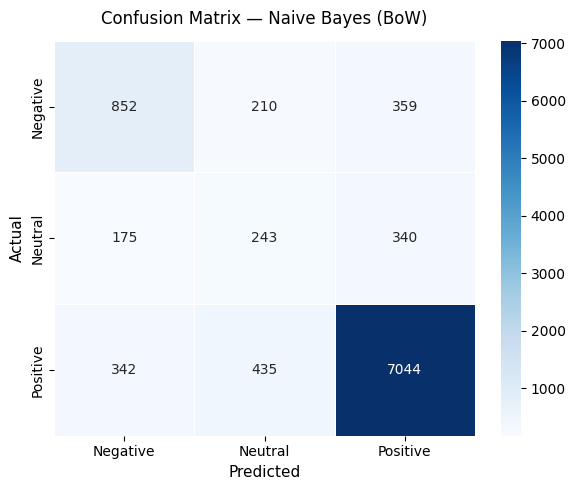

✅ Naive Bayes saved


In [4]:
nb_model = MultinomialNB(alpha=1.0)   # alpha=1 is Laplace smoothing
nb_model.fit(X_train_bow, y_train)
y_pred_nb = nb_model.predict(X_test_bow)

evaluate_model('Naive Bayes (BoW)', y_test, y_pred_nb)
plot_confusion_matrix('Naive Bayes (BoW)', y_test, y_pred_nb)

# Save model
with open('../models/naive_bayes.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
print("✅ Naive Bayes saved")


  Logistic Regression (TF-IDF)
  Accuracy  : 0.7039
  F1 Macro  : 0.5345

              precision    recall  f1-score   support

    Negative       0.40      0.84      0.54      1421
     Neutral       0.21      0.30      0.25       758
    Positive       0.96      0.72      0.82      7821

    accuracy                           0.70     10000
   macro avg       0.52      0.62      0.53     10000
weighted avg       0.82      0.70      0.74     10000



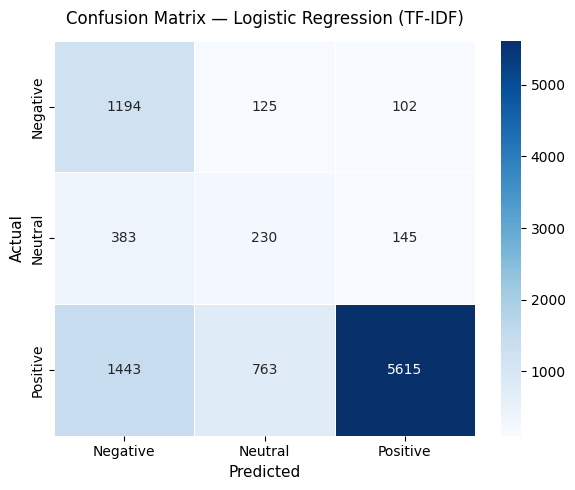

✅ Logistic Regression saved


In [5]:
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='saga',
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

evaluate_model('Logistic Regression (TF-IDF)', y_test, y_pred_lr)
plot_confusion_matrix('Logistic Regression (TF-IDF)', y_test, y_pred_lr)

with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✅ Logistic Regression saved")


  Random Forest (TF-IDF)
  Accuracy  : 0.8353
  F1 Macro  : 0.5303

              precision    recall  f1-score   support

    Negative       0.90      0.33      0.49      1421
     Neutral       0.99      0.11      0.20       758
    Positive       0.83      1.00      0.91      7821

    accuracy                           0.84     10000
   macro avg       0.91      0.48      0.53     10000
weighted avg       0.85      0.84      0.79     10000



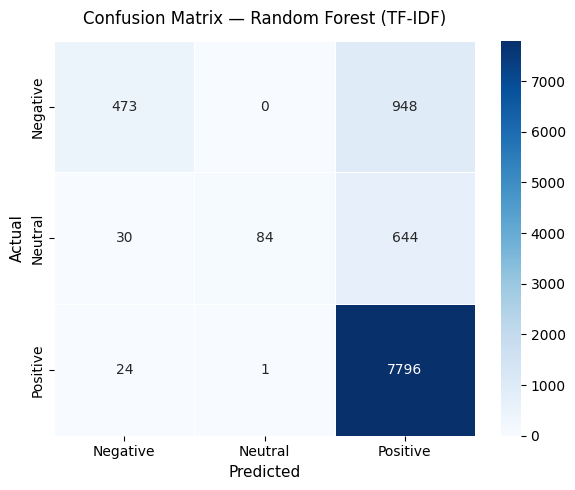

✅ Random Forest saved


In [6]:
rf_model = RandomForestClassifier(
    n_estimators=200,         # 200 decision trees
    max_depth=None,           # trees grow until pure
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,                # use all CPU cores
)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

evaluate_model('Random Forest (TF-IDF)', y_test, y_pred_rf)
plot_confusion_matrix('Random Forest (TF-IDF)', y_test, y_pred_rf)

with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✅ Random Forest saved")

In [7]:
# LSTM needs integer sequences, not TF-IDF vectors
MAX_VOCAB  = 20000   # top 20k words
MAX_LEN    = 150     # pad/truncate all reviews to 150 words

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

# Convert text → integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences to same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Vocabulary size : {len(tokenizer.word_index):,}")
print(f"Train padded shape: {X_train_pad.shape}")
print(f"Test  padded shape: {X_test_pad.shape}")

# Save tokenizer for Week 4
with open('../models/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer saved")

Vocabulary size : 28,243
Train padded shape: (40000, 150)
Test  padded shape: (10000, 150)
✅ Tokenizer saved


In [8]:
# EMBEDDING_DIM = 100
# NUM_CLASSES   = 3

# # Build model
# lstm_model = Sequential([
#     Embedding(MAX_VOCAB, EMBEDDING_DIM, input_length=MAX_LEN),
#     SpatialDropout1D(0.3),
#     LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
#     GlobalMaxPooling1D(),
#     Dense(64, activation='relu'),
#     Dropout(0.3),
#     Dense(NUM_CLASSES, activation='softmax'),
# ])

# lstm_model.compile(
#     loss='sparse_categorical_crossentropy',
#     optimizer='adam',
#     metrics=['accuracy']
# )

# lstm_model.summary()

# # Train
# early_stop = EarlyStopping(
#     monitor='val_loss', patience=2,
#     restore_best_weights=True, verbose=1
# )

# history = lstm_model.fit(
#     X_train_pad, y_train,
#     epochs=10,
#     batch_size=256,
#     validation_split=0.1,
#     callbacks=[early_stop],
#     verbose=1,
# )

# lstm_model.save('../models/lstm_model.keras')
# print("✅ LSTM model saved")

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights for the 3 classes (0=Negative, 1=Neutral, 2=Positive)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"Class weights: {class_weight_dict}")
# Expect Neutral (class 1) to get the highest weight since it's the rarest

EMBEDDING_DIM = 100
NUM_CLASSES   = 3

lstm_model = Sequential([
    Embedding(MAX_VOCAB, EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax'),
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss', patience=3,   
    restore_best_weights=True, verbose=1
)

history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15,                          
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight_dict,    
    
    verbose=1,
)

lstm_model.save('../models/lstm_model.keras')
print("✅ LSTM model saved (with class weights)")

Class weights: {0: 2.3461786615050735, 1: 4.396087482140895, 2: 0.42620295784852746}
Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 100s 655ms/step - accuracy: 0.5969 - loss: 0.9676 - val_accuracy: 0.6525 - val_loss: 0.8506
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 108s 764ms/step - accuracy: 0.7427 - loss: 0.7488 - val_accuracy: 0.6990 - val_loss: 0.7095
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 92s 654ms/step - accuracy: 0.7805 - loss: 0.6353 - val_accuracy: 0.7165 - val_loss: 0.6747
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 95s 672ms/step - accuracy: 0.8085 - loss: 0.5425 - val_accuracy: 0.7402 - val_loss: 0.6353
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 106s 754ms/step - accuracy: 0.8325 - loss: 0.4636 - val_accuracy: 0.7412 - val_loss: 0.6611
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 137s 972ms/step - accuracy: 0.8483 - loss: 0.4067 - val_accuracy: 0.7435 - val_loss: 0.6801
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 126s 894ms/step - accuracy: 0.8668 - loss: 0.3511 - val_accuracy: 0.7755 - val_loss: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step

  LSTM
  Accuracy  : 0.7363
  F1 Macro  : 0.5825

              precision    recall  f1-score   support

    Negative       0.59      0.63      0.61      1421
     Neutral       0.20      0.54      0.29       758
    Positive       0.95      0.78      0.85      7821

    accuracy                           0.74     10000
   macro avg       0.58      0.65      0.58     10000
weighted avg       0.84      0.74      0.77     10000



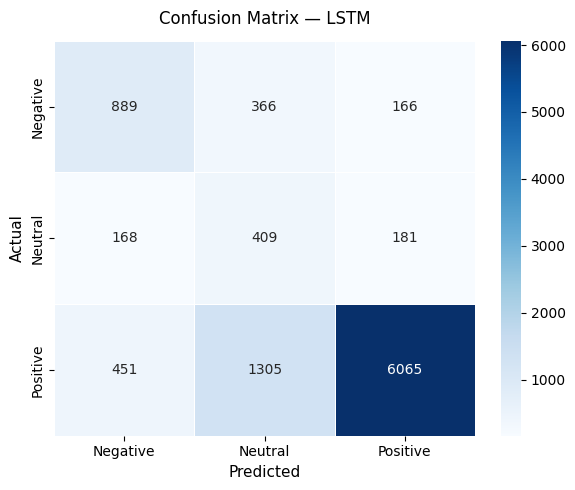

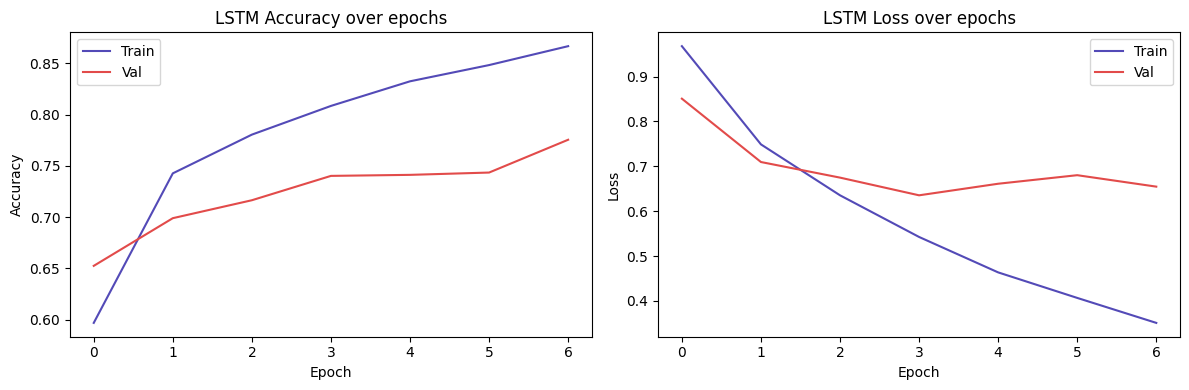

In [9]:
# Evaluate
y_pred_lstm_proba = lstm_model.predict(X_test_pad)
y_pred_lstm       = np.argmax(y_pred_lstm_proba, axis=1)

evaluate_model('LSTM', y_test, y_pred_lstm)
plot_confusion_matrix('LSTM', y_test, y_pred_lstm)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train', color='#534AB7')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='#E24B4A')
axes[0].set_title('LSTM Accuracy over epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', color='#534AB7')
axes[1].plot(history.history['val_loss'], label='Val',   color='#E24B4A')
axes[1].set_title('LSTM Loss over epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/lstm_training_curves.png', bbox_inches='tight')
plt.show()

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters : {'C': 10.0, 'solver': 'lbfgs'}
Best CV F1 Macro: 0.6181

  LR Tuned (TF-IDF)
  Accuracy  : 0.8163
  F1 Macro  : 0.6271

              precision    recall  f1-score   support

    Negative       0.61      0.68      0.64      1421
     Neutral       0.29      0.39      0.33       758
    Positive       0.93      0.88      0.91      7821

    accuracy                           0.82     10000
   macro avg       0.61      0.65      0.63     10000
weighted avg       0.84      0.82      0.83     10000



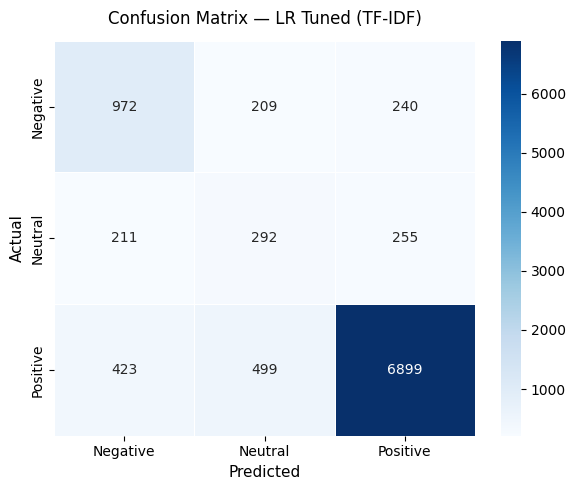

✅ Tuned LR saved


In [10]:
param_grid = {
    'C':      [0.01, 0.1, 1.0, 10.0],
    'solver': ['saga', 'lbfgs'],
}

grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1,
)

grid_search.fit(X_train_tfidf, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV F1 Macro: {grid_search.best_score_:.4f}")

y_pred_tuned = grid_search.best_estimator_.predict(X_test_tfidf)
evaluate_model('LR Tuned (TF-IDF)', y_test, y_pred_tuned)
plot_confusion_matrix('LR Tuned (TF-IDF)', y_test, y_pred_tuned)

with open('../models/lr_tuned.pkl', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)
print("✅ Tuned LR saved")


  MODEL COMPARISON — SENTISHOP 
                       Model  Accuracy  F1 Macro  F1 Positive  F1 Neutral  F1 Negative
           LR Tuned (TF-IDF)    0.8163    0.6271       0.9069      0.3322       0.6422
           Naive Bayes (BoW)    0.8139    0.6037       0.9052      0.2953       0.6108
                        LSTM    0.7363    0.5825       0.8522      0.2882       0.6070
Logistic Regression (TF-IDF)    0.7039    0.5345       0.8207      0.2452       0.5377
      Random Forest (TF-IDF)    0.8353    0.5303       0.9060      0.1993       0.4856


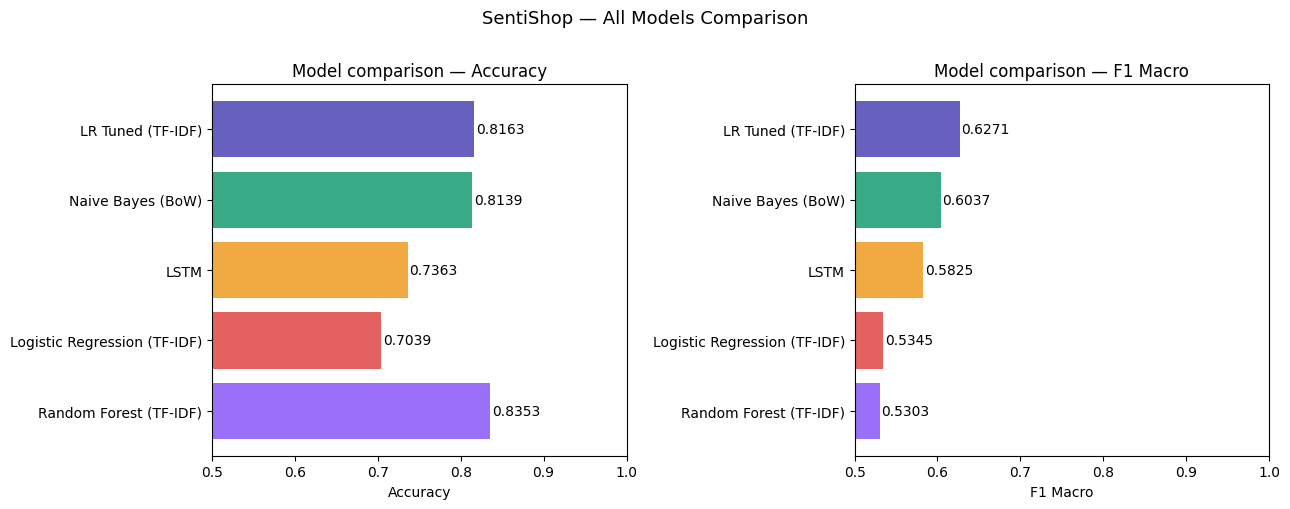

In [11]:
# Build results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("  MODEL COMPARISON — SENTISHOP ")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Save to CSV
results_df.to_csv('../outputs/model_comparison.csv', index=False)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_colors = ['#534AB7', '#1D9E75', '#EF9F27', '#E24B4A', '#8B5CF6']

for ax, metric in zip(axes, ['Accuracy', 'F1 Macro']):
    bars = ax.barh(results_df['Model'], results_df[metric],
                   color=bar_colors[:len(results_df)],
                   edgecolor='none', alpha=0.88)
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel(metric)
    ax.set_title(f'Model comparison — {metric}', fontsize=12)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
    ax.invert_yaxis()

plt.suptitle('SentiShop — All Models Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', bbox_inches='tight')
plt.show()

In [13]:
# Sort by F1 Macro to see overall ranking
results_df_sorted = results_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)

best_balanced = results_df_sorted.iloc[0]              # best F1 Macro
best_accuracy = results_df_sorted.sort_values('Accuracy', ascending=False).iloc[0]  # best accuracy

print("=" * 70)
print("  TWO RECOMMENDED MODELS — DIFFERENT BUSINESS PRIORITIES")
print("=" * 70)

print(f"\n🎯 OPTION 1 — Best Overall Balance: {best_balanced['Model']}")
print(f"   Accuracy   : {best_balanced['Accuracy']:.4f}")
print(f"   F1 Macro   : {best_balanced['F1 Macro']:.4f}")
print(f"   Use case   : Best choice when you care equally about catching")
print(f"                Negative, Neutral, AND Positive reviews accurately.")

print(f"\n⚡ OPTION 2 — Best Raw Accuracy: {best_accuracy['Model']}")
print(f"   Accuracy   : {best_accuracy['Accuracy']:.4f}")
print(f"   F1 Macro   : {best_accuracy['F1 Macro']:.4f}")
print(f"   Use case   : Best choice when overall correctness matters most")
print(f"                and Positive reviews dominate your review volume.")

print("\n✅ complete!")
print("Saved artifacts:")
print("  models/naive_bayes.pkl")
print("  models/logistic_regression.pkl")
print("  models/random_forest.pkl")
print("  models/lstm_model.keras")
print("  models/lr_tuned.pkl")
print("  outputs/model_comparison.csv")
print("  outputs/model_comparison.png")

# Save both recommendations for Week 4
results_df_sorted.to_csv('../outputs/model_comparison.csv', index=False)

  TWO RECOMMENDED MODELS — DIFFERENT BUSINESS PRIORITIES

🎯 OPTION 1 — Best Overall Balance: LR Tuned (TF-IDF)
   Accuracy   : 0.8163
   F1 Macro   : 0.6271
   Use case   : Best choice when you care equally about catching
                Negative, Neutral, AND Positive reviews accurately.

⚡ OPTION 2 — Best Raw Accuracy: Random Forest (TF-IDF)
   Accuracy   : 0.8353
   F1 Macro   : 0.5303
   Use case   : Best choice when overall correctness matters most
                and Positive reviews dominate your review volume.

✅ complete!
Saved artifacts:
  models/naive_bayes.pkl
  models/logistic_regression.pkl
  models/random_forest.pkl
  models/lstm_model.keras
  models/lr_tuned.pkl
  outputs/model_comparison.csv
  outputs/model_comparison.png
